# estatjp: Getting Started

Created: 2026-03-31

This tutorial provides a complete walk-through from registering at the e-Stat portal to plotting a dataset retrieve from it using `estatjp`. 

    - Register on the e-Stat portal get an API application ID
    - Find a dataset (monthly residential migration between Japanese prefectures and outside Japan since 2020)
    - Prune the dataset to fit in e-Stat's limit of 100,000 cells
    - Grab the pruned dataset's API query url
    - Use `estatjp` to download the dataset and obtain a Python DataFrame
    - Filter the raw DataFrame to isolate a final DataFrame (specific to Ibaraki Prefecture)
    - Plot the data (monthly migration inbound and outbound for Japanese and non-Japanese residents)

Most of the e-Stat portal and its data are in Japanese but there is as [English portal](https://www.e-stat.go.jp/en). This and other tutorials for `estatjp` will mainly focus on the English portal with occasional use of the [Japanese portal](https://www.e-stat.go.jp/).

## Register on the e-Stat portal and get an application ID

### Navigate to the [English portal](https://www.e-stat.go.jp/en)

The first task is to register (free) by clicking on "Sign Up" in the upper right corner and following the instructions.

<a href="https://www.e-stat.go.jp/en" ><img src="../../docs/images/estat-top-nonregistered-en.jpg" width=800 alt="e-Stat portal top page" /></a>


### Log in and navigate to 'My page'

<a href="https://www.e-stat.go.jp/en" ><img src="../../docs/images/estat-top-logged-in-en.jpg" width=800 alt="e-Stat portal top page" /></a>

### On 'My page' dashboard, click on 'API function (application ID issuance)'

<a href="https://www.e-stat.go.jp/en/mypage/view/dashboard" ><img src="../../docs/images/estat-dashboard-top.jpg" width=800 alt="e-Stat portal dashboard" /></a>


### Under 'API functions', complete name, URL and Overview boxes (follow arrow), then click on 'Issue'.

You can issue yourself up to 3 appIds.

<a href="https://www.e-stat.go.jp/en/mypage/view/api" ><img src="../../docs/images/estat-dashboard-api.jpg"  width=800 alt="e-Stat portal dashboard" style="border: 1px solid black" /></a>

### Add your app-id to your Python project and install `estatjp`.

```
pip install python-dotenv
dotenv set ESTAT_APP_ID your-app-id
pip install estatjp
```

## Example: Monthly stats on immigration and emigration of Japanese and non-Japanese by prefecture

For this task, we go back to the [top page](https://www.e-stat.go.jp/en) and look to the bottom left where there is a column titled "What's new". This column lists recent postings and updates. For each posting, there is a button labeled "DB" or one labeled "File" or both. The DB button means that there are databases that can be accessed via API calls. The File button means that there are files, usually in Excel or PDF format that can be downloaded. For this task, I am interested in immigration click on the DB button for the posting titled, "Report on Internal Migration in Japan". (You don't have to be logged in to e-Stat for these remaining steps.)

<a href="https://www.e-stat.go.jp/en" ><img src="../../docs/images/estat-top-whats-new-en.jpg" width=300 alt="e-Stat What's New column" /></a>


### Drilling down

This brings up a rather busy top page for the [Report on Internal Migration in Japan](https://www.e-stat.go.jp/en/stat-search/database?page=1&layout=normal&toukei=00200523). For this initial tutorial, I will ignore the detail and click through to our destination. This column list our desired Report with 253 datasets, a number that will likely change by the time this tutorial is viewed because this report is updated monthly. 

<a href="https://www.e-stat.go.jp/en/stat-search/database?page=1&layout=normal&toukei=00200523&tstat=000000070001" ><img src="../../docs/images/estat-migration-report-top-en.jpg" width=600 alt="e-Stat Migration Report Top" /></a>

### Drill deeper

Clicking on the above listing brings up a detailed listing that is headed by a monthly report that has 11 datasets.

<a href="https://www.e-stat.go.jp/en/stat-search/database?page=1&layout=datalist&toukei=00200523&tstat=000000070001&cycle=1&tclass1=000001008739&tclass2val=0" ><img src="../../docs/images/estat-migration-report-depth1-en.jpg" width=600 alt="e-Stat Migration Report Detailed listing" /></a>


### Paydirt

Clicking on the monthly report link brings up a [list of datasets](https://www.e-stat.go.jp/en/stat-search/database?page=1&layout=datalist&toukei=00200523&tstat=000000070001&cycle=1&tclass1=000001008739&tclass2val=0). 

<a href="https://www.e-stat.go.jp/en/stat-search/database?page=1&layout=datalist&toukei=00200523&tstat=000000070001&cycle=1&tclass1=000001008739&tclass2val=0" ><img src="../../docs/images/estat-migration-report-list-of-datasets-en.jpg" width=600 alt="e-Stat Migration Report list of datasets" /></a>

At the very bottom of this list is a dataset with the title "Number of In-migrants from overseas, Out-migrants to overseas and Deleted ex officio by sex for Japan,Prefectures and 21 Major Cities (All nationalities, Japanese and Foreigners) (from Jan. 2020)" and with buttons labeled "DB" and "API". 

<img src="../../docs/images/estat-migration-report-target-dataset-en.jpg" width=500 alt="e-Stat Migration Report target dataset" />

## Prune the dataset

Clicking on it brings up a popup box labeled "API Request URL". Selecting "CSV" and clicking on the button "Copy URL" gets a URL that enables download of the entire table. (Upcoming versions of `estatjp` will also accommodate XML and JSON.) However, the whole table contains summed categories, for example, "Both sexes" and its components "Female" and "Male". It also contains counts for 21 major cities and the total for Japan, while this tutorial focuses on the prefectures. The whole table also contains 139,860 cells and the maximum allowed in an API call is 100,000, so our download would be truncated. To avoid that, select the "DB" button. This brings up the table shown below.

<img src="../../docs/images/estat-migration-report-target-whole-table-en.jpg" width=500 alt="e-Stat Migration Report dataset whole table" />

Clicking on the "Select display item" at left opens the panel shown below.

<img src="../../docs/images/estat-migration-report-target-category-selection-en.jpg" width=400 alt="e-Stat Migration Report dataset category selection panel" />

Deselecting categories "Both sexes" and "All nationalities" and deselecting all areas that are not prefectures (screenshots omitted) removes unwanted categories and reduces the cell count to 41,736.

<img src="../../docs/images/estat-migration-report-target-selected-categories-en.jpg" width=400 alt="e-Stat Migration Report dataset category selection panel after deselection" />

Clicking on "Proceed" closes the selection panel and displays the filtered table. 

<img src="../../docs\images\estat-migration-report-target-filtered-table-en.jpg" width=400 alt="e-Stat Migration Report dataset filtered" />

## Grab the pruned dataset's API query url

Clicking on the "API" button at right brings up the popup box labeled "API Request URL" from which we can copy a useable URL.

<img src="../../docs/images/estat-migration-report-target-dataset-API-request-URL-popup-en.jpg" width=500 alt="e-Stat Migration Report dataset API Request URL popup" />

Now we can close the e-Stat tab and proceed with our local Python task.

Note that the API provides data in column-oriented orientation. (See [Data orientation](https://en.wikipedia.org/wiki/Data_orientation))

## Use `estatjp` to download the dataset

Install the required packages.

In [35]:
%%capture capt
# %%capture puts the output in 'capt' from which it can be ignored or printed
%pip install pandas
%pip install plotly 
%pip install matplotlib
%pip install python-dotenv # for using local environment variables
%pip install fsspec # to help pandas IO. See https://pandas.pydata.org/docs/user_guide/io.html#reading-writing-remote-files
%pip install requests
%pip install estatjp

In [3]:
# URL from e-Stat website:
requesturl = "http://api.e-stat.go.jp/rest/3.0/app/getSimpleStatsData?cdArea=01000%2C02000%2C03000%2C04000%2C05000%2C06000%2C07000%2C08000%2C09000%2C10000%2C11000%2C12000%2C13000%2C14000%2C15000%2C16000%2C17000%2C18000%2C19000%2C20000%2C21000%2C22000%2C23000%2C24000%2C25000%2C26000%2C27000%2C28000%2C29000%2C30000%2C31000%2C32000%2C33000%2C34000%2C35000%2C36000%2C37000%2C38000%2C39000%2C40000%2C41000%2C42000%2C43000%2C44000%2C45000%2C46000%2C47000&cdCat01=1%2C2&cdCat02=64000%2C65000&appId=&lang=E&statsDataId=0003423635&metaGetFlg=Y&cntGetFlg=N&explanationGetFlg=Y&annotationGetFlg=Y&sectionHeaderFlg=1&replaceSpChars=0"

import pandas as pd
import numpy
import os
from dotenv import load_dotenv
import requests
import tempfile
import re
import datetime
from estatjp import api
from estatjp import exceptions as xs
try:        
    dfs = api.get_csv_data(requesturl,description=datetime.datetime.now())
except Exception as e:
    print(type(e))
    print(e.args)
    print(e.with_traceback)

print("This is the metadata.")
print(dfs.get('Header'))

This is the metadata.
                       0                                                  1  \
0                 RESULT                                                NaN   
1                 STATUS                                                  0   
2              ERROR_MSG       The process has been successfully completed.   
3                   DATE                      2026-04-02T09:07:52.819+09:00   
4             RESULT_INF                                                NaN   
5           TOTAL_NUMBER                                              39480   
6            FROM_NUMBER                                                  1   
7              TO_NUMBER                                              39480   
8              TABLE_INF                                         0003423635   
9              STAT_NAME                                           00200523   
10               GOV_ORG                                              00200   
11       STATISTICS_NAME  Repo

In [4]:
print("This is the main data frame.")
print(dfs.get('Main'))
    

This is the main data frame.
       tab_code         Tabulated variable  cat01_code     Sex  cat02_code  \
0            15  In-migrants from overseas           1    Male       64000   
1            15  In-migrants from overseas           1    Male       64000   
2            15  In-migrants from overseas           1    Male       64000   
3            15  In-migrants from overseas           1    Male       64000   
4            15  In-migrants from overseas           1    Male       64000   
...         ...                        ...         ...     ...         ...   
39475        17         Deleted ex officio           2  Female       65000   
39476        17         Deleted ex officio           2  Female       65000   
39477        17         Deleted ex officio           2  Female       65000   
39478        17         Deleted ex officio           2  Female       65000   
39479        17         Deleted ex officio           2  Female       65000   

      Nationality  area_code      

## Filter the raw DataFrame to isolate a final DataFrame

The routines below use `pandas` and `plotly` packages to extract and plot the migration of residents between Ibaraki Prefecture and outside Japan between January 2021 and February 2026.

In [5]:
maindf = dfs.get('Main')
print(maindf.columns)


Index(['tab_code', 'Tabulated variable', 'cat01_code', 'Sex', 'cat02_code',
       'Nationality', 'area_code', 'Area', 'time_code', 'Year', 'unit',
       'value', 'annotation'],
      dtype='str')


,tab_code,Tabulated variable,cat01_code,Sex,cat02_code,Nationality,area_code,Area,time_code,Year,unit,value,annotation
518,15,In-migrants from overseas,1,Male,64000,Japanese,8000,Ibaraki-ken,2026000202,Feb. 2026,persons,65,NaN
519,15,In-migrants from overseas,1,Male,64000,Japanese,8000,Ibaraki-ken,2026000101,Jan. 2026,persons,109,NaN
520,15,In-migrants from overseas,1,Male,64000,Japanese,8000,Ibaraki-ken,2025001212,Dec. 2025,persons,47,NaN
521,15,In-migrants from overseas,1,Male,64000,Japanese,8000,Ibaraki-ken,2025001111,Nov. 2025,persons,63,NaN
522,15,In-migrants from overseas,1,Male,64000,Japanese,8000,Ibaraki-ken,2025001010,Oct. 2025,persons,81,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
37057,17,Deleted ex officio,2,Female,65000,Foreigners,8000,Ibaraki-ken,2021000505,May 2021,persons,56,NaN
37058,17,Deleted ex officio,2,Female,65000,Foreigners,8000,Ibaraki-ken,2021000404,Apr. 2021,persons,88,NaN
37059,17,Deleted ex officio,2,Female,65000,Foreigners,8000,Ibaraki-ken,2021000303,Mar. 2021,persons,145,NaN
37060,17,Deleted ex officio,2,Female,65000,Foreigners,8000,Ibaraki-ken,2021000202,Feb. 2021,persons,122,NaN


### Let's look at the factors

The factors and dates all have codes and labels. The following use grouping to identify them.

In [6]:
migrants = maindf[['tab_code','Tabulated variable']]
migrants
migrants.groupby(['tab_code','Tabulated variable']).count()


,
tab_code,Tabulated variable
15,In-migrants from overseas
16,Out-migrants to overseas
17,Deleted ex officio


In [7]:
sexes = maindf[['cat01_code','Sex']]
sexes
sexes.groupby(['cat01_code','Sex']).count()

,
cat01_code,Sex
1,Male
2,Female


"Both sexes" is the sum of "Male" and "Female". Below, "All nationalities" is the sum of "Japanese" and "Foreigners". Care must be taken not to double count for these columns.

In [16]:
nationalities = maindf[['cat02_code','Nationality']]
nationalities
nationalities.groupby(['cat02_code','Nationality']).count()

,
cat02_code,Nationality
64000,Japanese
65000,Foreigners


In [17]:
areas = maindf[['area_code', 'Area']]
areas
areas.groupby(['area_code', 'Area']).count()

,
area_code,Area
1000,Hokkaido
2000,Aomori-ken
3000,Iwate-ken
4000,Miyagi-ken
5000,Akita-ken
6000,Yamagata-ken
7000,Fukushima-ken
8000,Ibaraki-ken
9000,Tochigi-ken


In [18]:
dates = maindf[['time_code', 'Year']]
dates
dates.groupby(['time_code', 'Year']).count()

,
time_code,Year
2020000101,Jan. 2020
2020000202,Feb. 2020
2020000303,Mar. 2020
2020000404,Apr. 2020
2020000505,May 2020
...,...
2025001010,Oct. 2025
2025001111,Nov. 2025
2025001212,Dec. 2025


### Filter the raw DataFrame to isolate a final DataFrame (specific to Ibaraki Prefecture)

In [11]:
ibarakiset = maindf.query('Area == "Ibaraki-ken"')
ibarakiseries = ibarakiset.get(['Tabulated variable','Sex','Nationality','time_code','value', 'unit']) # Select the columns that I want to work with
# Instead of using the Year column to create a Period column, extract this info from the time_code column and convert it
ibarakiseries['Year'] = ((ibarakiseries['time_code'] / 1000000).astype(int)) #extract the year
ibarakiseries['Month'] = ((ibarakiseries['time_code'] % 100).astype(int)) # extract the month
idx = pd.Series(ibarakiseries['Year'].astype(str)).add('-').add(ibarakiseries['Month'].astype(str).add('-1')) # a series of dates, the 1st day of each month
idx = pd.PeriodIndex(idx, freq='M') # create the PeriodIndex
idx = idx.to_timestamp() # convert to TimeStamp series
ibarakiseries["Period"] = idx.to_period('M') # convert to Period column
ibarakiseries = ibarakiseries.get(['Tabulated variable','Sex','Nationality','Period','value', 'unit']) # the result
ibarakiseries

,Tabulated variable,Sex,Nationality,Period,value,unit
518,In-migrants from overseas,Male,Japanese,2026-02,65,persons
519,In-migrants from overseas,Male,Japanese,2026-01,109,persons
520,In-migrants from overseas,Male,Japanese,2025-12,47,persons
521,In-migrants from overseas,Male,Japanese,2025-11,63,persons
522,In-migrants from overseas,Male,Japanese,2025-10,81,persons
...,...,...,...,...,...,...
37057,Deleted ex officio,Female,Foreigners,2021-05,56,persons
37058,Deleted ex officio,Female,Foreigners,2021-04,88,persons
37059,Deleted ex officio,Female,Foreigners,2021-03,145,persons
37060,Deleted ex officio,Female,Foreigners,2021-02,122,persons


### Group and sum over gender

In [12]:
ibarakiagg = ibarakiseries.groupby(['Tabulated variable','Nationality','Period'], sort=False).sum()
ibarakiagg

Sex  value  \
Tabulated variable        Nationality Period                       
In-migrants from overseas Japanese    2026-02  MaleFemale    109   
                                      2026-01  MaleFemale    206   
                                      2025-12  MaleFemale     97   
                                      2025-11  MaleFemale    119   
                                      2025-10  MaleFemale    168   
...                                                   ...    ...   
Deleted ex officio        Foreigners  2021-05  MaleFemale    197   
                                      2021-04  MaleFemale    313   
                                      2021-03  MaleFemale    380   
                                      2021-02  MaleFemale    320   
                                      2021-01  MaleFemale    414   

                                                         unit  
Tabulated variable        Nationality Period                   
In-migrants from overseas Japanese    2026-02  personspersons  
                                      2026-01  personspersons  
                                      2025-12  personspersons  
                                      2025-11  personspersons  
                                      2025-10  personspersons  
...                                                       ...  
Deleted ex officio        Foreigners  2021-05  personspersons  
                                      2021-04  personspersons  
                                      2021-03  personspersons  
                                      2021-02  personspersons  
                                      2021-01  personspersons  

[420 rows x 3 columns]

### Ungroup to get the time series to be plotted below

In [13]:
ibarakifinal = ibarakiagg.reset_index().get(['Tabulated variable','Nationality','Period','value'])
ibarakifinal

,Tabulated variable,Nationality,Period,value
0,In-migrants from overseas,Japanese,2026-02,109
1,In-migrants from overseas,Japanese,2026-01,206
2,In-migrants from overseas,Japanese,2025-12,97
3,In-migrants from overseas,Japanese,2025-11,119
4,In-migrants from overseas,Japanese,2025-10,168
...,...,...,...,...
415,Deleted ex officio,Foreigners,2021-05,197
416,Deleted ex officio,Foreigners,2021-04,313
417,Deleted ex officio,Foreigners,2021-03,380
418,Deleted ex officio,Foreigners,2021-02,320


## Plot the data

### Extract the series to be plotted

In [155]:
natjpn = 'Japanese'
natfor = 'Foreigners'
inbound = 'In-migrants from overseas'
outbound = 'Out-migrants to overseas'
deleted = 'Deleted ex officio'

jpin = ibarakifinal.query('(Nationality == @natjpn) & (`Tabulated variable` == @inbound)') # note use of grave accents (backticks) to enclose and multiword column name
jpin = jpin.sort_values(by=["Period"])

jpout = ibarakifinal.query('(Nationality == @natjpn) & (`Tabulated variable` == @outbound)')
jpout = jpout.sort_values(by=["Period"])

forin = ibarakifinal.query('(Nationality == @natfor) & (`Tabulated variable` == @inbound)')
forin = forin.sort_values(by=["Period"])

forout = ibarakifinal.query('(Nationality == @natfor) & (`Tabulated variable` == @outbound)')
forout = forout.sort_values(by=["Period"])

jpdel = ibarakifinal.query('(Nationality == @natjpn) & (`Tabulated variable` == @deleted)')
jpdel = jpdel.sort_values(by=["Period"])

fordel = ibarakifinal.query('(Nationality == @natfor) & (`Tabulated variable` == @deleted)')
fordel = fordel.sort_values(by=["Period"])


### And plot them

In [170]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

xticks = jpin['Period']
xticks = xticks[xticks.apply(lambda x : x.month == 1)]
xlbls = xticks.apply(lambda y : y.year)


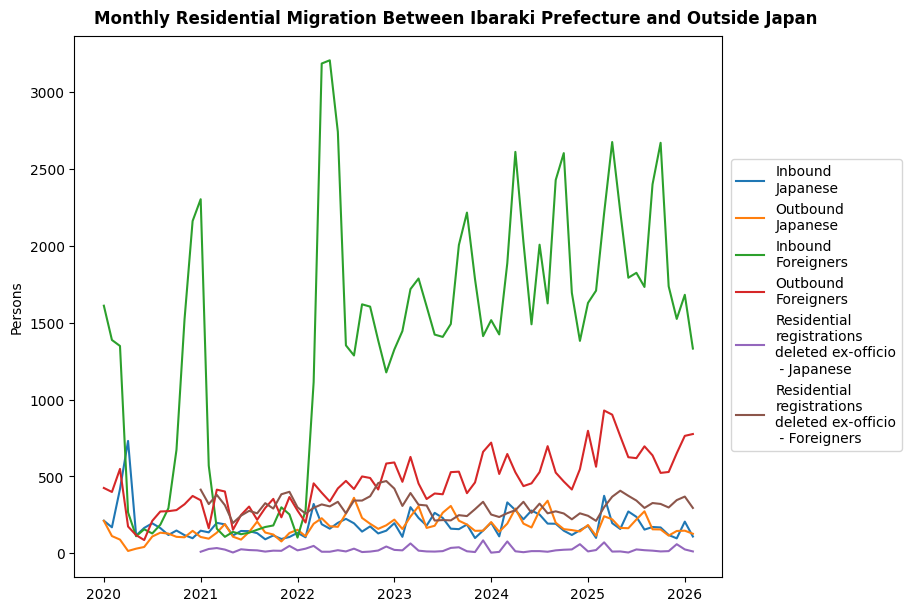

In [183]:

fig, ax = plt.subplots(figsize=(9, 6), layout='constrained')
fig.suptitle('Monthly Residential Migration Between Ibaraki Prefecture and Outside Japan', fontsize=12, fontweight='bold')
ax.plot(jpin['Period'].apply(lambda x : x.strftime("%Y-%m")), jpin["value"], label="Inbound\nJapanese")
ax.plot(jpout['Period'].apply(lambda x : x.strftime("%Y-%m")), jpout["value"], label="Outbound\nJapanese")
ax.plot(forin['Period'].apply(lambda x : x.strftime("%Y-%m")), forin["value"], label="Inbound\nForeigners")
ax.plot(forout['Period'].apply(lambda x : x.strftime("%Y-%m")), forout["value"], label="Outbound\nForeigners")
ax.plot(jpdel['Period'].apply(lambda x : x.strftime("%Y-%m")), jpdel["value"], label="Residential\nregistrations\ndeleted ex-officio\n - Japanese")
ax.plot(fordel['Period'].apply(lambda x : x.strftime("%Y-%m")), fordel["value"], label="Residential\nregistrations\ndeleted ex-officio\n - Foreigners")
ax.set_xticks(ticks = xticks.astype(str), labels = xlbls.astype(str))
ax.set_ylabel('Persons')
fig.legend(loc='outside right center')
#plt.show()
plt.savefig("../images/getting-started-result.jpg")


This completes this walk-through. Modify it to get at the data you want.